# Implementing ReLU

The rectified linear unit (or ReLU) function is one of the most common activation functions in deep learning.

It overcomes the training problems linked with the sigmoid function you learned, such as the vanishing gradients problem.

In this exercise, you'll begin with a ReLU implementation in PyTorch. Next, you'll calculate the gradients of the function.

In [6]:
import torch.nn as nn
import torch

# Create a ReLU function with PyTorch
relu_pytorch = nn.ReLU()

# Apply your ReLU function on x, and calculate gradients
x = torch.tensor(-1.0, requires_grad=True)
y = relu_pytorch(x)
y.backward()

# Print the gradient of the ReLU function for x
gradient = x.grad
print(gradient)

tensor(0.)


# Implementing leaky ReLU

You've learned that ReLU is one of the most used activation functions in deep learning. You will find it in modern architecture. However, it does have the inconvenience of outputting null values for negative inputs and therefore, having null gradients. Once an element of the input is negative, it will be set to zero for the rest of the training. Leaky ReLU overcomes this challenge by using a multiplying factor for negative inputs.

In [8]:
# Create a leaky relu function in PyTorch
leaky_relu_pytorch = nn.LeakyReLU(negative_slope=0.05)

x = torch.tensor(-2.0)
# Call the above function on the tensor x
output = leaky_relu_pytorch(x)
print(output)

tensor(-0.1000)


# Understanding activation functions

You've learned all about ReLU vs. leaky ReLU. Which of the following statements are true?

- The ReLU activation function only outputs zero for negative inputs.
- ReLU(x) = 3 for x = 3.

# Counting the number of parameters

Deep learning models are famous for having a lot of parameters. Recent language models have billions of parameters. With more parameters comes more computational complexity and longer training times, and a deep learning practitioner must know how many parameters their model has.

In this exercise, you will calculate the number of parameters in your model, first using PyTorch then manually.

In [26]:
model = nn.Sequential(nn.Linear(16, 4),
                      nn.Linear(4, 2),
                      nn.Linear(2, 1))

total = 0

# Calculate the number of parameters in the model
for params in model.parameters():
  total = total + params.numel()
print(f"total parameters = {total}")

total parameters = 81


# Manipulating the capacity of a network

In this exercise, you will practice creating neural networks with different capacities. The capacity of a network reflects the number of parameters in said network

In [27]:
def calculate_capacity(model):
  total = 0
  for p in model.parameters():
    total += p.numel()
  return total

In [31]:
n_features = 8
n_classes = 2

input_tensor = torch.Tensor([[3, 4, 6, 2, 3, 6, 8, 9]])

# Create a neural network with less than 120 parameters
model = nn.Sequential(
    nn.Linear(8,6),
    nn.Linear(6,4),
    nn.Linear(4,2)
)
output = model(input_tensor)

print(calculate_capacity(model))

92


In [32]:
n_features = 8
n_classes = 2

input_tensor = torch.Tensor([[3, 4, 6, 2, 3, 6, 8, 9]])

# Create a neural network with more than 120 parameters
model = nn.Sequential(
    nn.Linear(8,8),
    nn.Linear(8,8),
    nn.Linear(8,8),
    nn.Linear(8,2)
)

output = model(input_tensor)

print(calculate_capacity(model))

234


# Experimenting with learning rate

In this exercise, your goal is to find the optimal learning rate such that the optimizer can find the minimum of the non-convex function in ten steps.

You will experiment with three different learning rate values. For this problem, try learning rate values between 0.001 to 0.1.

In [34]:

import numpy as np
import matplotlib.pyplot as plt
def optimize_and_plot(lr=0.01, momentum=0.0):
  x = torch.tensor(2.0, requires_grad=True)
  buffer = torch.zeros_like(x.data)
  values = []
  for i in range(10):

      y = function(x)
      values.append((x.clone(), y.clone()))
      y.backward()

      d_p = x.grad.data
      if momentum !=0 :
          buffer.mul_(momentum).add_(d_p)
          d_p = buffer

      x.data.add_(d_p, alpha=-lr)
      x.grad.zero_()
      
  x = np.arange(-3, 2, 0.001)
  y = function(x)

  plt.figure(figsize=(10, 5))
  plt.plot([v[0].detach().numpy() for v in values], [v[1].detach().numpy() for v in values], 'r-X', 
           linewidth=2, markersize=7)
  for i in range(10):
      plt.text(values[i][0]+0.1, values[i][1], f'step {i}', fontdict={'color': 'r'})
  plt.plot(x, y, linewidth=2)
  plt.grid()
  plt.tick_params(axis='both', which='major', labelsize=12)
  plt.legend(['Optimizer steps', 'Square function'])
  plt.show()

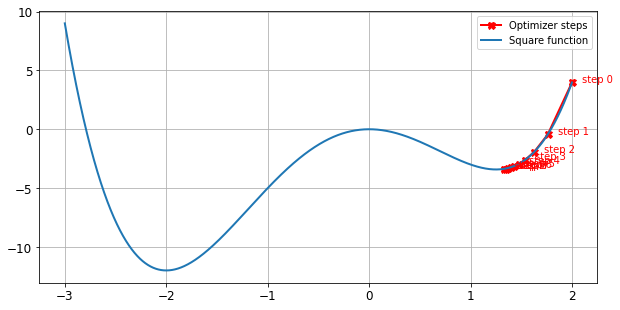

In [46]:
def function(x):
    return x**4 + x**3 - 5*x**2
    # return x**6 + x**5 - 5*x**4

# Try a first learning rate value
lr0 = 0.01
optimize_and_plot(lr=lr0)

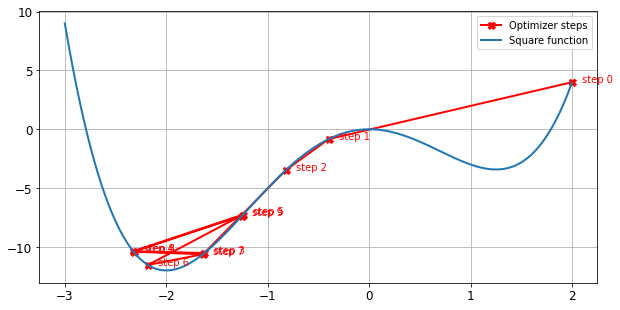

In [47]:
# Try a second learning rate value
lr1 = 0.1
optimize_and_plot(lr=lr1)

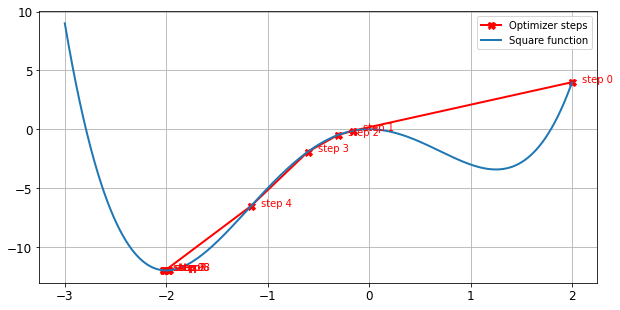

In [48]:
# Try a third learning rate value
lr2 = 0.09
optimize_and_plot(lr=lr2)

# Experimenting with momentum

In this exercise, your goal is to find the optimal momentum such that the optimizer can find the minimum of the following non-convex function in 20 steps. You will experiment with two different momentum values. For this problem, the learning rate is fixed at 0.01

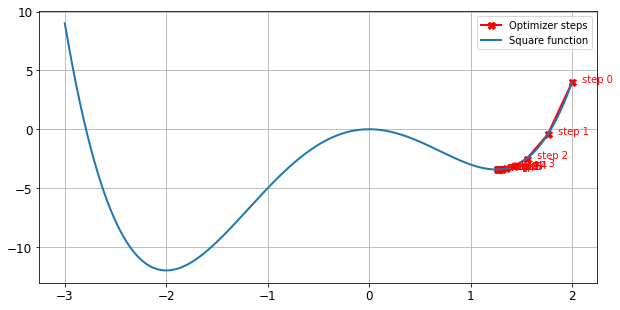

In [49]:
# Try a first value for momentum
mom0 = 0.3
optimize_and_plot(momentum=mom0)

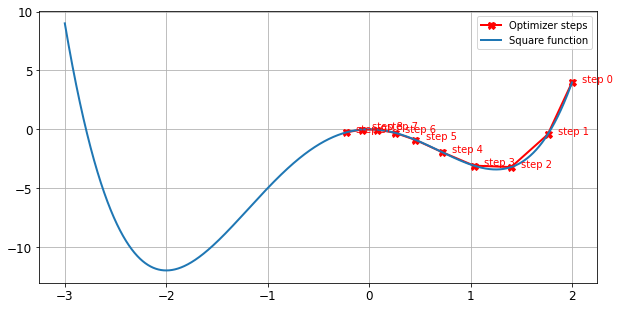

In [57]:
# Try a second value for momentum
mom1 = 0.94
optimize_and_plot(momentum=mom1)

# Fine-tuning process

You are training a model on a new dataset and you think you can use a fine-tuning approach instead of training from scratch (i.e., training from randomly initialized weights).

To fine-tune a model on a new task, you need to follow a certain number of steps that are listed here.

<center><img src="images/03.09.png"  style="width: 400px, height: 300px;"/></center>


# Freeze layers of a model

You are about to fine-tune a model on a new task after loading pre-trained weights. The model contains three linear layers. However, because your dataset is small, you only want to train the last linear layer of this model and freeze the first two linear layers.

In [62]:
from collections import OrderedDict

model = nn.Sequential(
    OrderedDict([
        ('layer1', nn.Linear(in_features=8, out_features=16, bias=True)),
        ('layer2', nn.Linear(in_features=16, out_features=32, bias=True)),
        ('layer3', nn.Linear(in_features=32, out_features=10, bias=True))
    ])
)

In [63]:
for name, param in model.named_parameters():
    print(name)

layer1.weight
layer1.bias
layer2.weight
layer2.bias
layer3.weight
layer3.bias


In [64]:
for name, param in model.named_parameters():    
  
    # Check if the parameters belong to the first layer
    if name == 'layer1.weight' or name == 'layer1.bias':
      
        # Freeze the parameters
        param.requires_grad = False
  
    # Check if the parameters belong to the second layer
    if name == 'layer2.weight' or name == 'layer2.bias':
      
        # Freeze the parameters
        param.requires_grad = False

# Layer initialization

The initialization of the weights of a neural network has been the focus of researchers for many years. When training a network, the method used to initialize the weights has a direct impact on the final performance of the network.

As a machine learning practitioner, you should be able to experiment with different initialization strategies. In this exercise, you are creating a small neural network made of two layers and you are deciding to initialize each layer's weights with the uniform method.

In [66]:
layer0 = nn.Linear(16, 32)
layer1 = nn.Linear(32, 64)

# Use uniform initialization for layer0 and layer1 weights
nn.init.uniform(layer0.weight)
nn.init.uniform(layer1.weight)

model = nn.Sequential(layer0, layer1)

C:\Users\88016\AppData\Local\Temp/ipykernel_23304/3606124447.py:5: UserWarning: nn.init.uniform is now deprecated in favor of nn.init.uniform_.
  nn.init.uniform(layer0.weight)
C:\Users\88016\AppData\Local\Temp/ipykernel_23304/3606124447.py:6: UserWarning: nn.init.uniform is now deprecated in favor of nn.init.uniform_.
  nn.init.uniform(layer1.weight)
